# Forward Propagation

In [5]:
import math 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

In [4]:
def f(x): # 임의의 함수 (x에 대응하는 하나의 값을 넣으면 하나의 정수가 답으로 나오는 함수)
    return 3*x**2 - 4*x + 5

In [5]:
f(3.0)

20.0

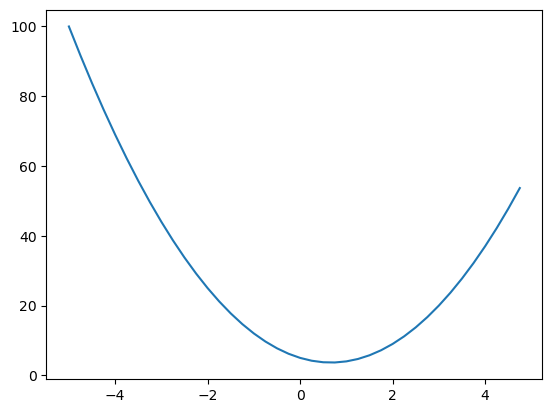

In [6]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [7]:
# 미분: $x$가 아주 미세하게 $h$만큼 변할 때, 함수값 $f(x)$가 변하는 정도(변화율). 
# $$\text{Slope} \approx \frac{f(x+h) - f(x)}{h}$$
# 기울기의 역할: 현재 위치에서 함수 $f(x)$를 가장 크게 키우는 방향을 알려줌.
#   기울기($k$): "지금 내 발밑의 경사가 어느 정도인가?"
#   이동($x_{new}$): "그 경사 방향으로 얼마나 갈 것인가?"
#   보통 다음과 같은 식으로 이동합니다:$$x_{new} = x - (\text{Learning Rate} \times \text{Slope})$$
# 학습의 원리: 우리는 Loss를 줄여야 하므로, 기울기의 반대 방향으로 조금씩 이동하여 최저점(Minimum)을 찾아감.

h = 0.000000001 
x = -3.0
((f(x+h) - f(x)))/h

-22.000001820288162

In [8]:
h = 0.000000001 
x = 2/3
((f(x+h) - f(x)))/h

0.0

In [9]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b+ c
print(d)

4.0


In [10]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

# a를 h만큼(미세하게 이동)
d1 = a*b+ c
a+=h
d2 = a*b+ c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

print("=======================")

# c를 h만큼(미세하게 이동)
# a도 c도 움직이면 d의 결과가 이동하지만(함수에 영향을 주지만), c는 단순히 더해지기 때문에 영향력(기울기) = 1 
# c로 미분하면 기울기는 1 
d1 = a*b+ c
c+=h
d2 = a*b+ c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772
d1 3.999699999999999
d2 3.9997999999999987
slope 0.9999999999976694


In [ ]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [12]:
a = Value(2.0)
b = Value(-3.0)
print(a)
print(b)

Value(data=2.0)
Value(data=-3.0)


In [13]:
# 파이썬은 objects를 더하는 방법을 모르기 때문에 덧셈 연산자를 정의해야 함 
# -> class 내부에서 정의 (이중 밑줄 (__)로 시작하는 특수 메서드 사용)
# 두 객체의 숫자를 더해서 새로운 Value 객체를 생성함 
# 왜 그냥 a+b로 하지 않는가?
#   - 그냥 2.0 + (-3.0)을 하게 되면 파이썬은 결과값 5.0만 주고, 5.0이 어디서 왔는지는 잊어버림
#   - class를 사용하면 a, b를 더해서 만들었다는 족보를 남길 수 있음 (연산 그래프)

# Python Operator Overloading: 
# __add__와 같은 특수 메서드를 사용해 객체 간 연산이 가능하도록 정의하며, 
# 이는 향후 **연산 그래프(Computational Graph)**를 자동으로 구축하기 위한 기초 작업이다.
# 파이썬의 빌트인 연산자(+, * 등)가 사용자 정의 객체에 대해 작동하도록 해당 객체의 매직 메서드(__add__, __mul__ 등)를 가로채어 정의하는 기법.

print(a+b)

Value(data=-1.0)


In [14]:
a*b

Value(data=-6.0)

In [15]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
# 위의 식은 사실상 이 식:(a.__num__(b)).__add__(c)

```
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c  # d = -6 + 10 = 4
```

위 코드를 실행하게 되면, _children 덕분에 메모리에 아래처럼 저장됨.

```
          d (data=4.0)
         / \
        /   \
    (add)    _prev = {더하기 결과, c}
      / \
    /    \
  곱하기  c
  / \    |
 a   b   |
```

- 각 노드의 _prev:
  - d._prev = {곱하기의 결과, c}
  - 곱하기 결과의 _prev = {a, b}
  - a, b, c의 _prev = {} (입력값이므로 부모가 없음)



In [16]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [17]:
d._op

'+'

In [8]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [19]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b
e.label = 'e'
d = e+c
d.label=d
f = Value(-2.0, label='f')
L = d * f
L.label = 'L'

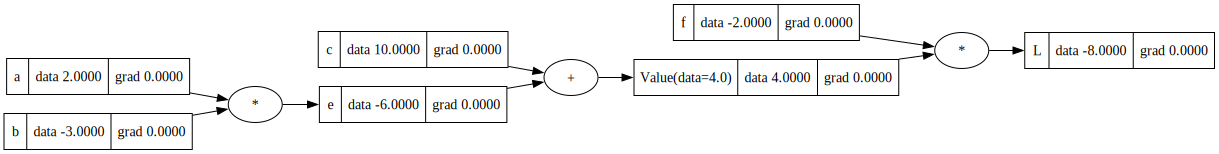

In [20]:
draw_dot(L)
# 이것이 순방향 전달 과정

# back Propagation

1. 두 미분값이 다른 이유 (수학적 원리)

두 `lol()` 함수의 차이는 **"어느 지점에서 변화($h$)를 주었는가"**입니다.

**첫 번째 코드: $L$에 직접 $h$를 더함**
* **상황:** 결과값 $L$이 아주 미세하게 변했을 때, $L$ 자체가 얼마나 변하는가?
* **계산:** $\frac{(L+h) - L}{h} = \frac{h}{h} = 1.0$
* **의미:** 자기 자신에 대한 미분값은 언제나 **1**입니다. 이것이 바로 모든 역전파의 시작점인 `L.grad = 1.0`이 되는 이유입니다.  

**두 번째 코드: 입력값 $a$에 $h$를 더함**
* **상황:** 입력값 $a$를 살짝 건드렸을 때, 머나먼 결과값 $L$은 얼마나 변하는가?
* **계산:** 아까 분석한 대로 $(-2.0 \times 1 \times -3.0) = \mathbf{6.0}$ 근처가 나옵니다.
* **의미:** $a$와 $L$ 사이에는 곱셈, 덧셈 등 여러 관문이 있습니다. 이 관문들을 거치면서 변화량이 증폭되거나 축소됩니다.  

2. Karpathy가 이 두 개를 보여준 의도

이 비교를 통해 Karpathy가 알려주고 싶어 하는 핵심은 **"기울기의 전파(Propagation)"**입니다.

**① 모든 미분은 끝에서부터 시작한다 ($L.grad = 1.0$)**
우리가 어떤 변수의 기울기를 구하든, 결국 그 영향력의 기준은 **"그래서 최종 Loss가 얼마나 변했는데?"**입니다. 첫 번째 코드는 **"기준점(1.0)을 잡는 법"**을 알려줍니다.

**② 체인 룰은 "영향력의 비율"을 곱하는 과정이다**
두 번째 코드를 통해 우리는 **"아, $a$를 바꾸면 $e$가 변하고, $e$가 변하면 $d$가 변하고, 결국 $L$이 변하는구나"**라는 연쇄 반응을 목격합니다.
* $L$ 입장에서 $d$는 $f(-2.0)$배 만큼 영향을 줍니다.
* $d$ 입장에서 $e$는 $1$배 만큼 영향을 줍니다.
* $e$ 입장에서 $a$는 $b(-3.0)$배 만큼 영향을 줍니다.
* **결론:** $(-2.0) \times 1 \times (-3.0) = 6.0$

> **수치 미분 대조의 교훈**
> 1. **자기 자신의 미분:** $dL/dL = 1.0$. 모든 역전파는 최종 노드에 기울기 1을 부여하며 시작된다.
> 2. **입력의 미분:** 입력이 출력에 미치는 영향력($dL/da$)은 중간 단계의 **국소적 기울기(Local Gradient)**들을 모두 곱한 값과 같다.
> 3. **검증 도구:** 우리가 앞으로 코딩할 `Value.backward()` 엔진이 내놓는 값이, 실제로 이 `lol()` 함수가 계산한 `(L2-L1)/h`와 일치하는지 확인하며 엔진의 정확성을 검증한다.

---



In [26]:
def lol():
  
  h = 0.0001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0 + h, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()

6.000000000021544


In [27]:
def lol():
  
  h = 0.0001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data + h
  
  print((L2 - L1)/h)
  
lol()

0.9999999999976694


In [28]:
L.grad = 1.0

In [29]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

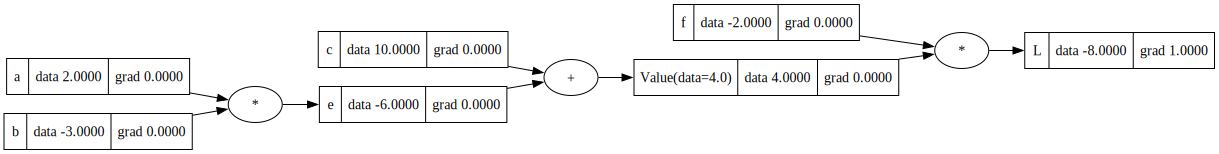

In [31]:
draw_dot(L)
# 이것이 순방향 전달 과정

- 단계별 유도
```
L = d * f

dL/dd =?  (d에 대해 L의 기울기는?)
```

**수치 미분으로 계산:**
$$\frac{dL}{dd} = \frac{L(d+h) - L(d)}{h}$$

**계산 과정:**
$$\frac{((d+h)*f) - (d*f)}{h}$$
$$= \frac{d*f + h*f - d*f}{h}$$
$$= \frac{h*f}{h}$$
$$= f$$

- 결론
$$\boxed{\frac{\partial L}{\partial d} = f}$$
즉, **L에 대한 d의 기울기는 f입니다!**

- 역전파의 핵심 (연쇄법칙)
```python
# 만약 L에 대한 f의 기울기를 원하면?
# dL/df = d

# 역전파:
# L이 d와 f로부터 만들어졌으므로
d.grad += f  # ← d의 기울기에 f를 더함
f.grad += d  # ← f의 기울기에 d를 더함
```
**일반 규칙:**
- $L = a * b$ 일 때:
  - $\frac{\partial L}{\partial a} = b$ 
  - $\frac{\partial L}{\partial b} = a$
이것이 **곱셈의 국소 기울기(Local Gradient)**입니다!

- 덧셈일 때는?
```
L = d + f
dL/dd = 1  (그냥 더하기니까)
dL/df = 1
```

In [32]:
f.grad = 4.0
d.grad = -2

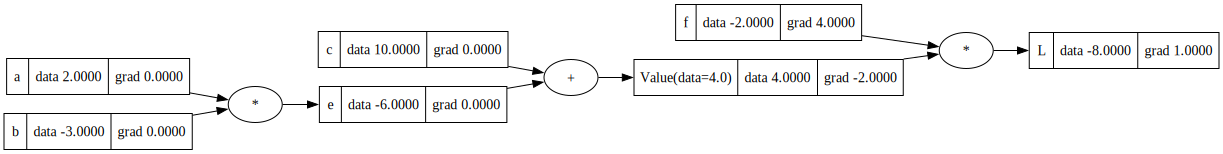

In [33]:
draw_dot(L)

1. 덧셈 노드의 로컬 미분 (Local Gradient)

$d = c + e$: $c$와 $e$를 더해서 $d$가 나왔죠.
$dd / dc$: "변수 $c$가 변할 때 결과 $d$는 얼마나 변하는가?"(기울기)를 묻는 질문입니다.
$(f(x+h) - f(x)) / h$: 아까 우리가 배운 미분의 기본 정의입니다.
$((c+h + e) - (c + e)) / h$:$f(x+h)$ 자리에 $c$ 대신 아주 작은 값 $h$를 더한 $(c+h+e)$를 넣었습니다.
$f(x)$ 자리에는 원래 식인 $(c+e)$를 넣었습니다.
$(c + h + e - c - e) / h$: 괄호를 풀어서 계산해보니 $c$와 $e$가 서로 빠져서 사라집니다.$h / h = 1.0$: 결국 $h$만 남고, $h$로 나누니 1.0이 됩니다.

**덧셈($+$)을 미분하면 무조건 $1$**이 나온다는 증명입니다.

* **수식:** $f(x, y) = x + y$ 일 때, $\frac{\partial f}{\partial x} = 1$, $\frac{\partial f}{\partial y} = 1$
* **의미:** 입력값 $x$가 $0.0001$ 변하면 결과값 $f$도 정확히 $0.0001$만큼 변한다는 뜻입니다.
* **비유:** 덧셈 노드는 아주 정직한 전달자입니다. 자기가 받은 변화를 뻥튀기하거나 깎지 않고 그대로 전달합니다.



---

## 2. 체인 룰 (Chain Rule: 연쇄 법칙)
체인 룰은 **"전체 기울기 = (상류에서 내려온 기울기) $\times$ (현재 노드의 로컬 기울기)"**라는 공식입니다.

우리가 구하고 싶은 것은 **"맨 마지막 $L$에 대해, 저 앞에 있는 $c$가 얼마나 영향을 주는가($\frac{dL}{dc}$)"**입니다. 하지만 $c$는 $L$과 바로 붙어있지 않죠? 그래서 중간 다리를 거칩니다.

$$\frac{dL}{dc} = \frac{dL}{dd} \times \frac{dd}{dc}$$

1.  **$\frac{dL}{dd}$ (Upstream Gradient):** $d$가 $L$에 주는 영향력. 이미 뒤에서 계산되어 배달된 값입니다.
2.  **$\frac{dd}{dc}$ (Local Gradient):** $c$가 $d$에 주는 영향력. 아까 증명한 **$1.0$**입니다.
3.  **최종 계산:** 배달된 값에 $1.0$을 곱하면 끝!



---

## 3. 덧셈 노드는 "기울기 배정자 (Distributor)"
이제 이 둘을 합치면 Karpathy가 왜 덧셈 노드를 **Distributor(분배기)**라고 부르는지 이해됩니다.

* 만약 $d$ 노드까지 전달된 기울기($\frac{dL}{dd}$)가 **$-2.0$**이었다면:
    * $c$의 기울기: $-2.0 \times 1.0 = \mathbf{-2.0}$
    * $e$의 기울기: $-2.0 \times 1.0 = \mathbf{-2.0}$
* **결론:** 덧셈 노드는 뒤에서 온 기울기를 **복사해서 모든 입력선에 똑같이 뿌려줍니다.**



---

### 📝 노션 정리용 최종 요약

| 개념 | 설명 | 비유 |
| :--- | :--- | :--- |
| **로컬 기울기** | 현재 연산($+$)만 봤을 때의 미분값 ($1.0$) | 우리 집 앞마당 청소 |
| **상류 기울기** | 최종 목적지($L$)에서 여기까지 흘러온 미분값 | 본사에서 내려온 지침 |
| **체인 룰** | (상류 기울기) $\times$ (로컬 기울기) | 본사 지침과 내 상황을 곱해 행동 결정 |
| **덧셈의 역할** | 기울기를 그대로 복사해서 전달 | **Gradient Distributor** |

아주 날카로운 질문입니다! 방금 보신 **$\frac{dL}{dc} = \frac{dL}{dd} \times \frac{dd}{dc}$**는 덧셈일 때만 쓰이는 공식이 아니라, 어떤 연산이든 적용되는 **미분의 대원칙(체인 룰)**입니다.

다만, 곱셈일 때는 저 공식 중에서 **$\frac{dd}{dc}$ (로컬 기울기)** 부분이 1.0이 아닌 다른 값으로 바뀔 뿐입니다.

---

## 1. 곱셈 연산의 미분 (Local Gradient)
곱셈 노드 $e = a \times b$가 있다고 해봅시다. $a$에 대해 미분하면 어떻게 될까요?

* **증명:** 아까 덧셈처럼 $((a+h) \times b - (a \times b)) / h$를 계산하면, $(ab + hb - ab) / h$가 되어 결국 **$b$**만 남습니다.
* **결론:** * $a$로 미분하면 상대방인 **$b$**가 나옵니다.
    * $b$로 미분하면 상대방인 **$a$**가 나옵니다.



---

## 2. 곱셈의 체인 룰 적용 (예시: $L = d \times f$)
Karpathy가 영상에서 `f.grad`를 구하는 과정을 곱셈의 체인 룰로 풀어볼게요.

$$\frac{dL}{df} = \frac{dL}{dL} \times \frac{dL}{df}$$

1.  **$\frac{dL}{dL}$ (상류 기울기):** 자기 자신에 대한 미분이니까 **1.0**입니다.
2.  **$\frac{dL}{df}$ (로컬 기울기):** $L = d \times f$니까, $f$에 대한 미분은 상대방인 **$d$**의 값입니다.
3.  **최종 결과:** $1.0 \times d.data$

그래서 Karpathy가 **"곱셈 노드의 기울기는 상대방의 값을 곱해주는 것과 같다"**고 말하는 겁니다.

---

## 3. 노션 정리용: 덧셈 vs 곱셈 비교 (Backprop 핵심)

노션에 이 표를 그려두면 헷갈릴 일이 없습니다. **'뒤에서 온 기울기'**를 어떻게 요리해서 앞으로 보낼지에 대한 전략입니다.

| 연산 | 로컬 미분 공식 | Backprop 동작 (기울기 전달 방식) | 비유 |
| :--- | :--- | :--- | :--- |
| **덧셈 ($+$)** | $1$ | 상류 기울기를 **그대로 복사**해서 전달 | **Distributor** (배분기) |
| **곱셈 ($*$)** | **상대방의 값** | 상류 기울기에 **상대방의 데이터를 곱해서** 전달 | **Switcher** (교환기) |

---

## 4. 왜 곱셈은 "Switcher"인가요?
예를 들어 $e = a \times b$에서 $a=2, b=-3$이고, 상류 기울기가 $1.0$이라고 칩시다.
* $a$의 기울기 = $1.0 \times b(-3) = \mathbf{-3.0}$
* $b$의 기울기 = $1.0 \times a(2) = \mathbf{2.0}$

보시다시피 $a$의 기울기를 구할 때 $b$의 값이 쓰이고, $b$의 기울기를 구할 때 $a$의 값이 쓰이죠? 그래서 Karpathy는 곱셈 노드가 **상대방의 값을 스위칭해서 기울기에 반영한다**고 설명합니다.



---

### 📝 최종 요약 (노션용)
> **체인 룰은 '곱하기 릴레이'다.**
> 1. 모든 노드는 **"상류 기울기 $\times$ 로컬 기울기"**를 계산해서 앞 노드로 던진다.
> 2. **덧셈($+$)의 로컬 기울기**는 무조건 **1**이므로, 기울기를 그대로 통과시킨다.
> 3. **곱셈($*$)의 로컬 기울기**는 **상대방 입력값**이므로, 기울기에 상대방 값을 곱해서 보낸다.

In [34]:
c.grad = -2.0
e.grad = -2.0

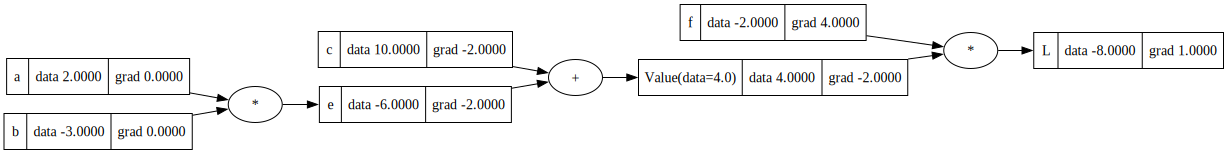

In [35]:
draw_dot(L)

dL / de = -2.0

e = a * b
de / da? b 

dL / da = (dL / de) * (de / da)

In [36]:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

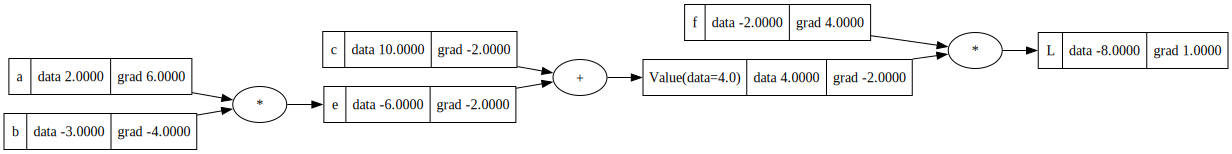

In [37]:
draw_dot(L)

이 지점이 바로 **"학습(Optimization)"**의 본질이 터져 나오는 순간입니다. 왜 기울기에 숫자를 곱해서 더하면 우리가 원하는 방향으로 숫자가 움직이는지, 아주 직관적으로 설명해 드릴게요.

결론부터 말씀드리면, **"기울기(grad)는 $L$을 '키우는' 방향을 알려주기 때문에, 그 방향으로 따라가면 $L$이 커진다"**는 원리입니다.

---

### 1. 기울기($grad$)의 진짜 의미
미분값(기울기)은 수학적으로 **"이 변수를 아주 조금 키웠을 때, 최종 결과 $L$이 어느 방향으로 얼마나 변하는가?"**를 나타냅니다.

* **$grad$가 양수($+$)라면:** "나를 키우면 $L$도 커져!"라는 뜻입니다.
* **$grad$가 음수($-$)라면:** "나를 키우면 $L$은 작아져!"라는 뜻입니다.

### 2. 왜 더하면 $L$이 커질까? (이미지의 상황)
이미지에서는 `+=`를 써서 **기울기 방향 그대로** 데이터를 수정하고 있습니다.

* 만약 `a.grad`가 **6.0**이었다면? $\rightarrow$ $a$를 키우면 $L$이 커진다는 뜻이죠.
* 여기에 `0.01 * 6.0`을 **더하면**, 실제로 $a$가 커집니다.
* 결과적으로 **$L$도 커지게 됩니다.**

Karpathy가 이 코드를 보여준 이유는, **"우리가 각 변수의 기울기를 알고 있다면, 우리가 원하는 대로 $L$을 조절(키우거나 줄이거나)할 수 있다"**는 것을 증명하기 위해서예요.


---

### 3. 노션 정리용: $L$을 조절하는 두 가지 방법

딥러닝에서는 보통 **Loss(오차)를 줄이는 것**이 목표지만, Karpathy는 지금 $L$을 **키우는** 시연을 하고 있습니다.

| 연산 | 명칭 | 목적 |
| :--- | :--- | :--- |
| **`data += step * grad`** | **Gradient Ascent** (경사 상승법) | $L$을 최대화할 때 (Karpathy 시연) |
| **`data -= step * grad`** | **Gradient Descent** (경사 하강법) | $L$(오차)을 최소화할 때 (**실제 딥러닝**) |

* **$0.01$ (Step size / Learning rate):** 너무 크게 움직이면 정답을 지나칠 수 있어서, 쥐꼬리만큼만 움직이게 조절하는 나사입니다.

---

### 4. 왜 $L$ 방향으로 "줄어드는" 게 아니라 "커지는" 걸까?
질문하신 내용 중에 "줄어든다"고 하셨는데, 이미지의 **`+=`** 코드를 그대로 실행하면 $L$은 **늘어납니다!**

만약 $L$이 오차(Loss)라서 **줄이고 싶다면**, Karpathy는 나중에 저 코드를 이렇게 바꿀 거예요:
> `a.data -= 0.01 * a.grad` (반대 방향으로 가기)

### 📝 노션 정리용 한 줄 요약
> **파라미터 업데이트 (Update Rule)**
> * **기울기($grad$):** $L$이 증가하는 방향을 가리키는 나침반.
> * **업데이트:** 데이터를 기울기 방향으로 더하면(`+=`) $L$이 커지고, 기울기 반대 방향으로 빼면(`-=`) $L$이 작아진다. 
> * 이것이 바로 수조 개의 파라미터를 가진 AI가 정답을 찾아가는 유일한 원리이다.

In [38]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


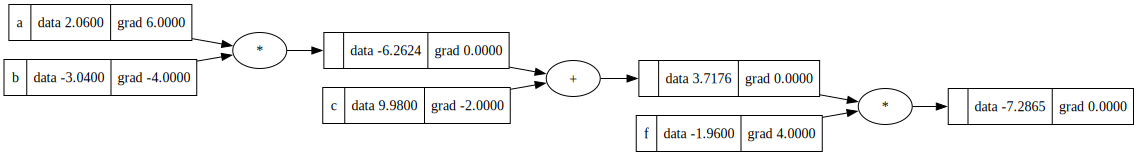

In [39]:
draw_dot(L)

# 수동 backprop

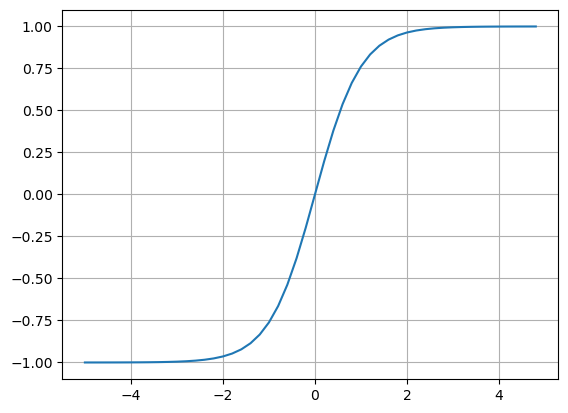

In [40]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [53]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

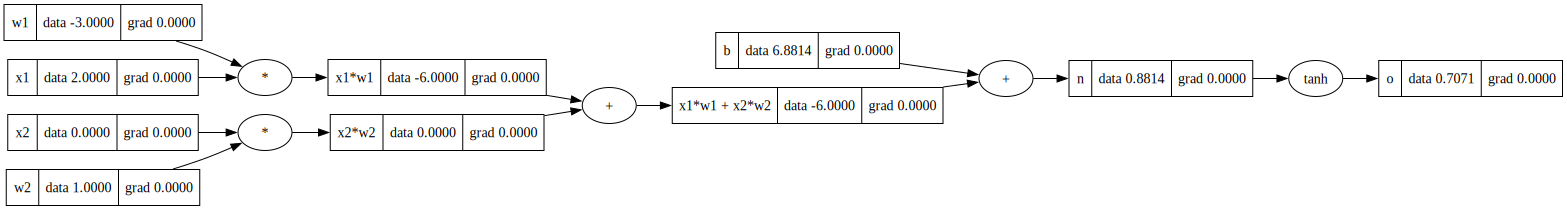

In [54]:
draw_dot(o)

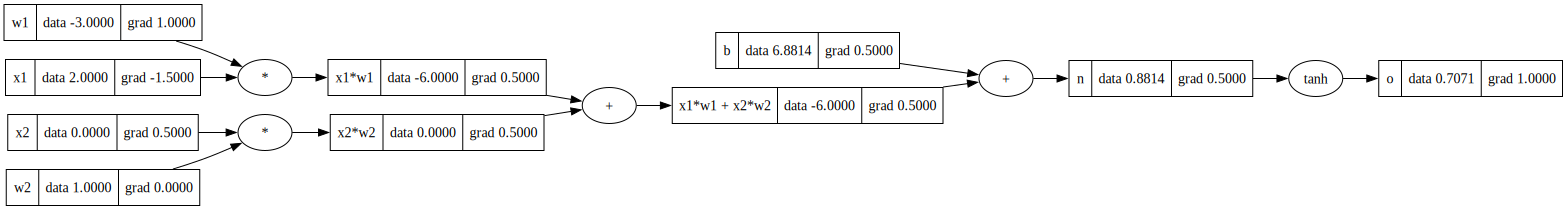

In [66]:
o.grad = 1.0 
draw_dot(o)

In [56]:
# o = tanh(n)
# do / dn = 1 - tanh(n)**2 = 1 - o**2 
o.data

0.7071067811865476

In [59]:
print(1 - o.data**2)

0.4999999999999999


In [60]:
n.grad = 0.5

In [62]:
b.grad = 0.5 
x1w1x2w2.grad = 0.5

In [64]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [65]:
x2.grad = w2.data * x2w2.grad 
w2.grad = x2.data * x2w2.grad 

x1.grad = w1.data * x2w2.grad 
w1.grad = x1.data * x2w2.grad 


# 자동 backprop(Value class update)

In [68]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

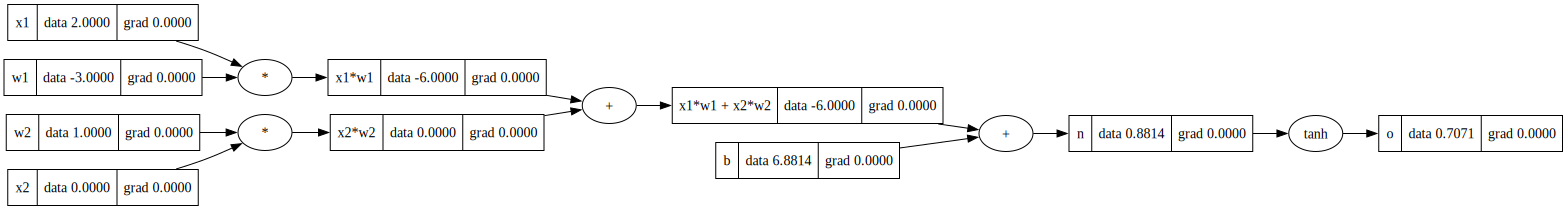

In [69]:
draw_dot(o)

In [70]:
o.grad = 1.0

o._backward()

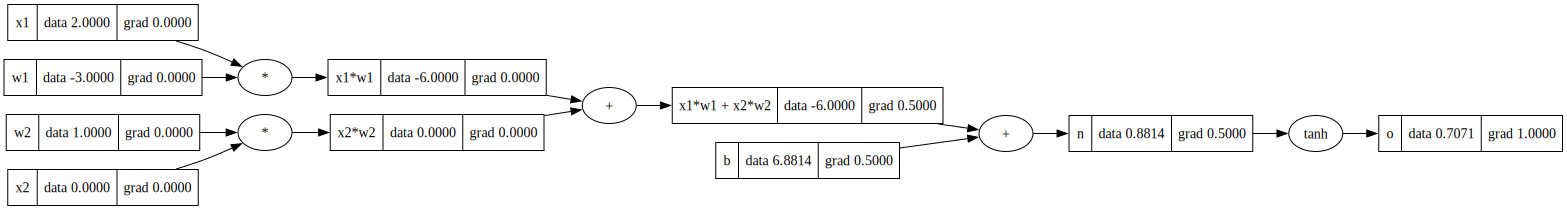

In [79]:
draw_dot(o)

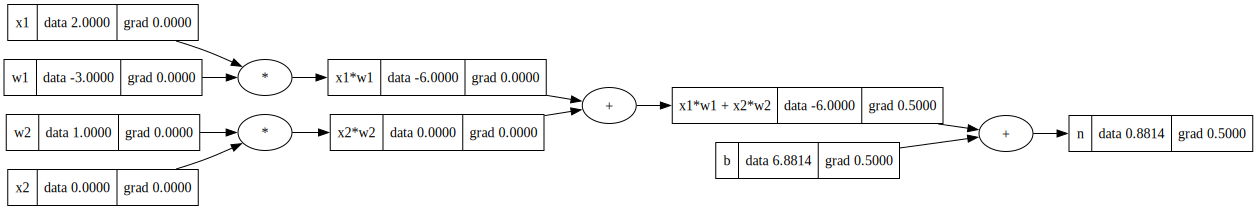

In [80]:
n._backward()
draw_dot(n)

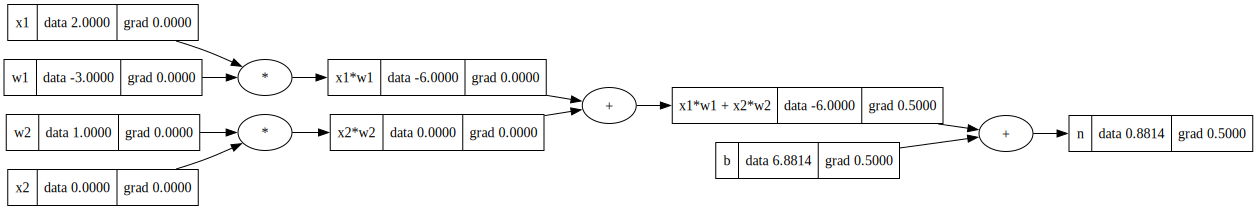

In [81]:
draw_dot(n)

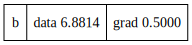

In [82]:
b._backward()
draw_dot(b)

In [83]:
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()

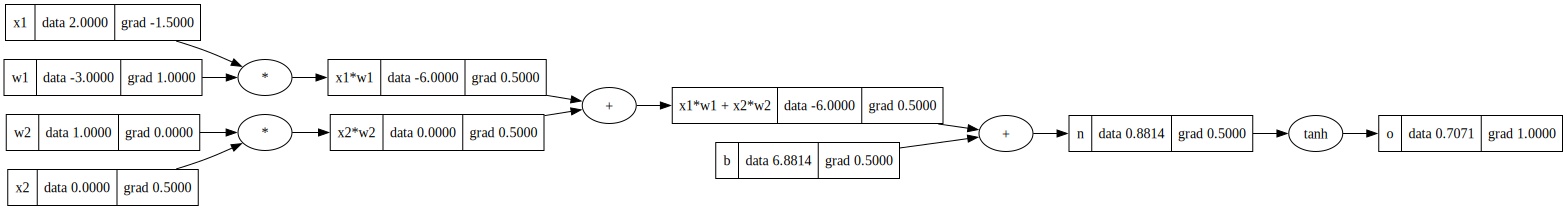

In [84]:
draw_dot(o)

# _backward



핵심은 이겁니다: **`_backward()`는 '한 칸'만 가는 화살표고, 위상정렬은 '전체 경로'를 알려주는 지도입니다.**

---

### 1. `_backward()`는 "나랑 내 부모"만 안다
우리가 만든 `_backward()` 함수를 다시 보세요.
* 예를 들어 `d = a + b`라면, `d._backward()`는 오직 **`a.grad`와 `b.grad`만 업데이트**하고 끝납니다. 
* 그 앞 단계인 `a`를 누가 만들었는지, `b`를 누가 만들었는지는 `d._backward()`가 상관할 바가 아니에요. 

즉, `_backward()`를 **한 번 실행한다고 해서 그래프 전체가 자동으로 촤르륵 미분되는 게 아닙니다.** 딱 한 단계만 뒤로 가는 거예요.

### 2. "종속성 유지"가 왜 위상정렬인가?
여기서 **종속성(Dependency)**이란, **"나보다 뒤에 있는 애들이 계산을 다 끝내야 내 값이 정확해진다"**는 뜻입니다.



* **문제 상황:** 변수 `x`가 `y`를 만드는 데도 쓰이고, `z`를 만드는 데도 쓰인다고 칩시다. (`x` $\rightarrow$ `y`, `x` $\rightarrow$ `z`)
* **잘못된 순서:** 만약 `y._backward()`는 실행했는데, 아직 `z._backward()`가 실행되지 않은 상태에서 `x._backward()`를 해버리면?
* **결과:** `x`는 `y`로부터 온 영향력만 받고 계산을 끝내버립니다. `z`가 줄 영향력은 무시되는 거죠.

**그래서 위상정렬이 필요합니다.** 위상정렬을 하면 "모든 자식(결과물)이 부모(입력물)보다 먼저 리스트에 나오는 순서"를 보장해줍니다. 이 순서대로 `_backward()`를 호출해야만 **누락되는 영향력 없이 종속성을 완벽히 유지**할 수 있습니다.

---

### 3. 전체 메커니즘 (정리)

1.  **위상정렬 (Topological Sort):** 전체 그래프를 훑어서 `[결과, 중간1, 중간2, ..., 입력]` 순서로 리스트를 만듭니다. (이게 **지도**를 그리는 과정입니다.)
2.  **반복문 실행:** 그 리스트를 돌면서 각 노드의 `_backward()`를 **순서대로** 누릅니다.
    * 결과.`_backward()` 호출 $\rightarrow$ 중간 노드들 grad 채워짐
    * 중간1.`_backward()` 호출 $\rightarrow$ 그 앞 노드들 grad 채워짐
    * ... (반복)

### 📝 노션 정리용 한 줄 요약
> **왜 위상정렬 후 `_backward`를 부르는가?**
> * `_backward`는 로컬(한 단계) 연산일 뿐이므로, 전체 그래프의 미분값이 누락 없이 **누적(Accumulate)** 되게 하려면 반드시 **자식 노드가 부모 노드보다 먼저 실행되는 순서(위상 순서)**를 지켜야 하기 때문이다.

---

3. 노션 정리용: 역전파 자동화 3단계
자동 역전파(Autograd)의 완성 과정

순전파(Forward Pass): 연산을 수행하며 각 노드에 _backward 함수(공식)를 예약해둔다.

정렬(Topological Sort): _prev 족보를 이용해 모든 노드를 올바른 실행 순서로 정렬한다.

일괄 실행(The Grand Loop): 정렬된 리스트를 역순으로 순회하며 예약된 _backward()를 호출한다.

4. 언더스코어(_)의 의미 다시 보기
_backward (함수): 각 연산자가 가진 개별 미분 공식 (아직 실행 안 됨).

backward (메서드): 우리가 최종적으로 호출할 녀석. 내부적으로 위상 정렬을 수행하고 모든 _backward를 순서대로 실행해주는 총지휘관.

In [85]:
topo = [] 
visited = set() 

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
print(topo)

[Value(data=0.0), Value(data=1.0), Value(data=0.0), Value(data=2.0), Value(data=-3.0), Value(data=-6.0), Value(data=-6.0), Value(data=6.881373587019543), Value(data=0.8813735870195432), Value(data=0.7071067811865476)]


In [6]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

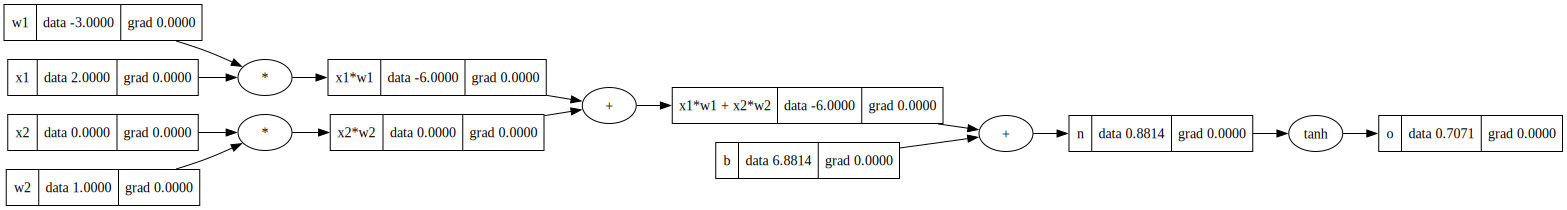

In [9]:
draw_dot(o)

In [ ]:
o.grad = 1.0

topo = [] 
visited = set() 

def build_topo(v): # 재귀구조: o에서 시작해서 거꾸로 올라간 후, 부모를 만났을 때 topo 시작
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for node in reversed(topo): # 역전파를 위해 reverse
    node._backward()

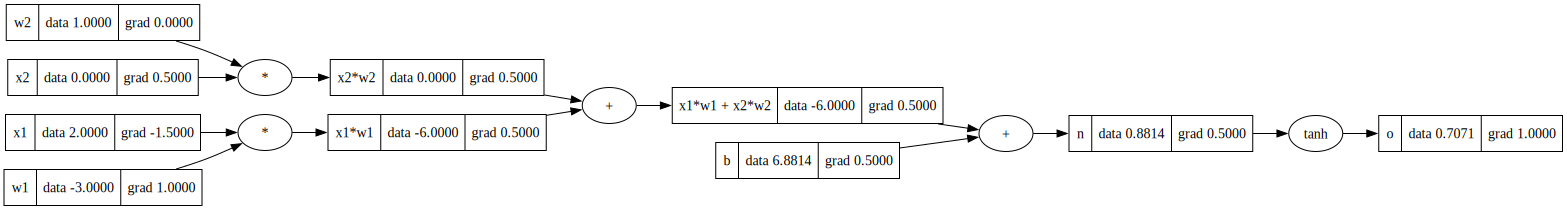

In [89]:
draw_dot(o)

In [10]:
o.backward()

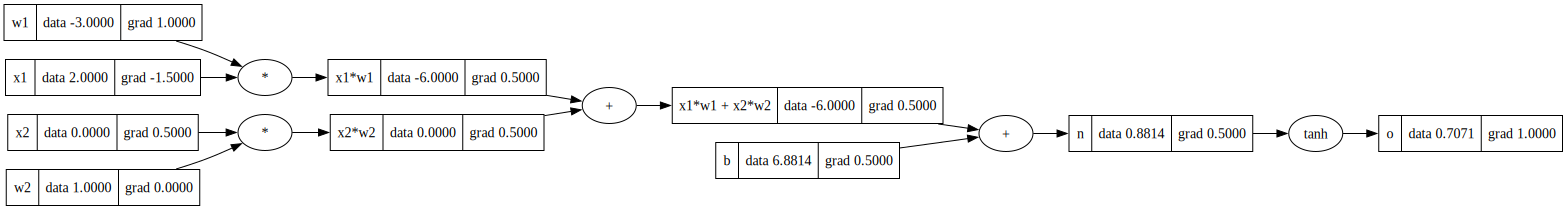

In [11]:
draw_dot(o)

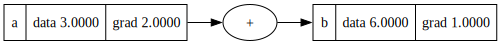

In [13]:
a = Value(3.0, label='a')
b = a + a ; b.label = 'b'
b.backward()
draw_dot(b)

# tanh 뽀개기 (Breaking up a tanh)

# Comparison with Pytorch

# Building MLP

# Dataset & Loss

# Collecting Parameters

# Gradient Descent Optimization